**Pre Processing**

Data Cleaning
- Check Data Type
- Check Missing Value
- Check Duplicate 
- Check Outlier

EDA 
- Numerical Feature
- Categorical Feature



In [2]:
# Library

import pandas as pd
import numpy as np


# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import missingno as msno
from IPython.display import display

**A. Pemahaman Data**


In [3]:
#Load Dataset
df = pd.read_csv("CarPrice_Assignment.csv")
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [5]:
#Check Data Type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

data type sudah sesuai dengan jenis fitur dan labelnya

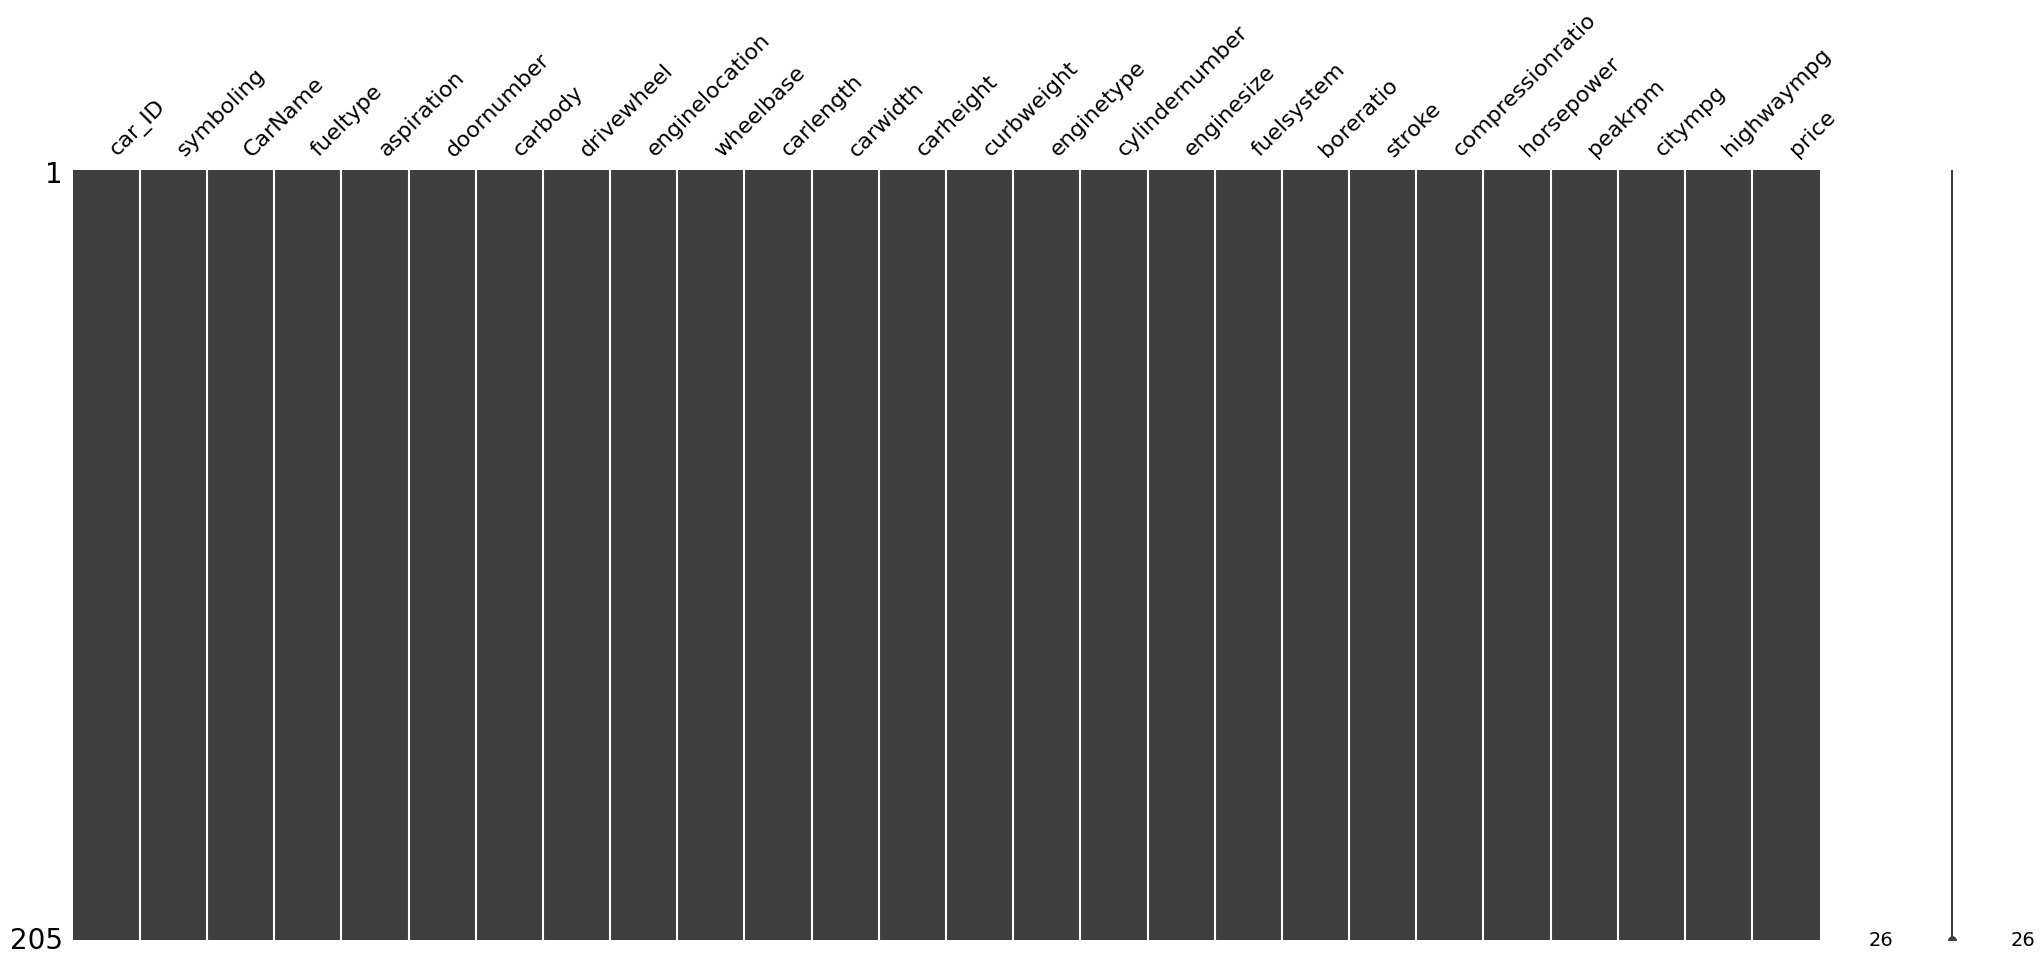

In [ ]:
# Check & visualisasi missing value
msno.matrix(df);

In [ ]:
# Persentasi Missing Value per Kolom
listItem = []
for col in df.columns :
    listItem.append([col, df[col].dtype, df[col].isna().sum(), round((df[col].isna().sum()/len(df[col])) * 100,2),
                    ])

dfDesc = pd.DataFrame(columns=['dataFeatures', 'dataType', 'null', 'nullPct%'],
                     data=listItem)
dfDesc

,dataFeatures,dataType,null,nullPct%
0,car_ID,int64,0,0.0
1,symboling,int64,0,0.0
2,CarName,object,0,0.0
3,fueltype,object,0,0.0
4,aspiration,object,0,0.0
5,doornumber,object,0,0.0
6,carbody,object,0,0.0
7,drivewheel,object,0,0.0
8,enginelocation,object,0,0.0
9,wheelbase,float64,0,0.0


tidak ada missing value

In [10]:
#check Duplicate Data
df.duplicated().sum(), df.duplicated().sum() / len(df)

(0, 0.0)

Tidak terdapat duplikat data, pada dataset terdapat kolom `CarID` yang merupakan **primary key**.

### Numerical Feature



In [11]:
num_features = [feature for feature in df.columns if ((df[feature].dtypes != 'O'))]
num_features

['car_ID',
 'symboling',
 'wheelbase',
 'carlength',
 'carwidth',
 'carheight',
 'curbweight',
 'enginesize',
 'boreratio',
 'stroke',
 'compressionratio',
 'horsepower',
 'peakrpm',
 'citympg',
 'highwaympg',
 'price']

In [12]:
#Drop car_ID karena unique number tidak dipakai dalam analisis dan price merupakan label
num_features.remove('car_ID')
num_features.remove('price')
num_features

['symboling',
 'wheelbase',
 'carlength',
 'carwidth',
 'carheight',
 'curbweight',
 'enginesize',
 'boreratio',
 'stroke',
 'compressionratio',
 'horsepower',
 'peakrpm',
 'citympg',
 'highwaympg']

#### Pemeriksaan Distribusi

c:\Users\ACER\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\ACER\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\ACER\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\ACER\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option i

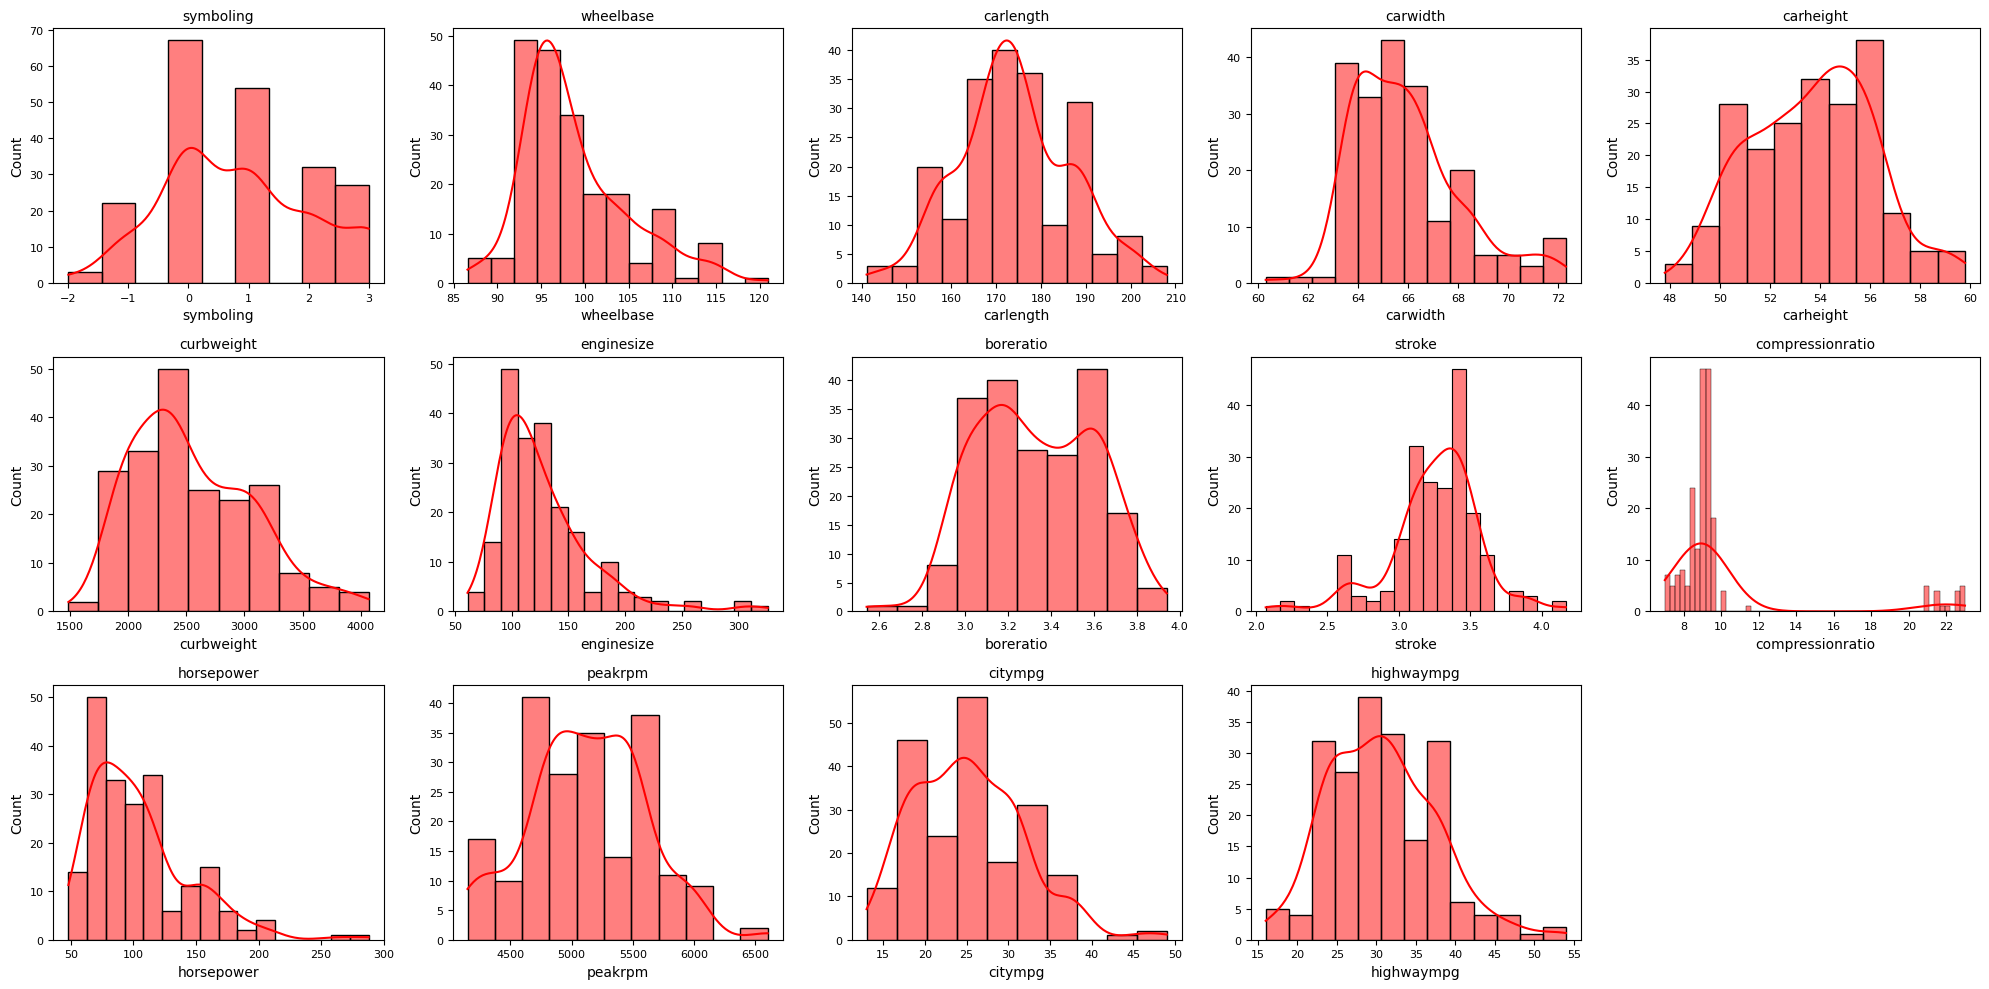

In [ ]:
# Jumlah kolom numerik
num_cols = len(num_features)

# Atur layout grid: misal 3 baris, 5 kolom
rows = 3
cols = 5

fig, axes = plt.subplots(rows, cols, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(data=df, x=col, kde=True, color='red', ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', labelsize=8)
    axes[i].tick_params(axis='y', labelsize=8)

# Hapus axes kosong kalau jumlah plot < jumlah grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [ ]:
# cek anomali sebaran
df[num_features].describe()

,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000


c:\Users\ACER\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\ACER\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\ACER\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\ACER\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecat

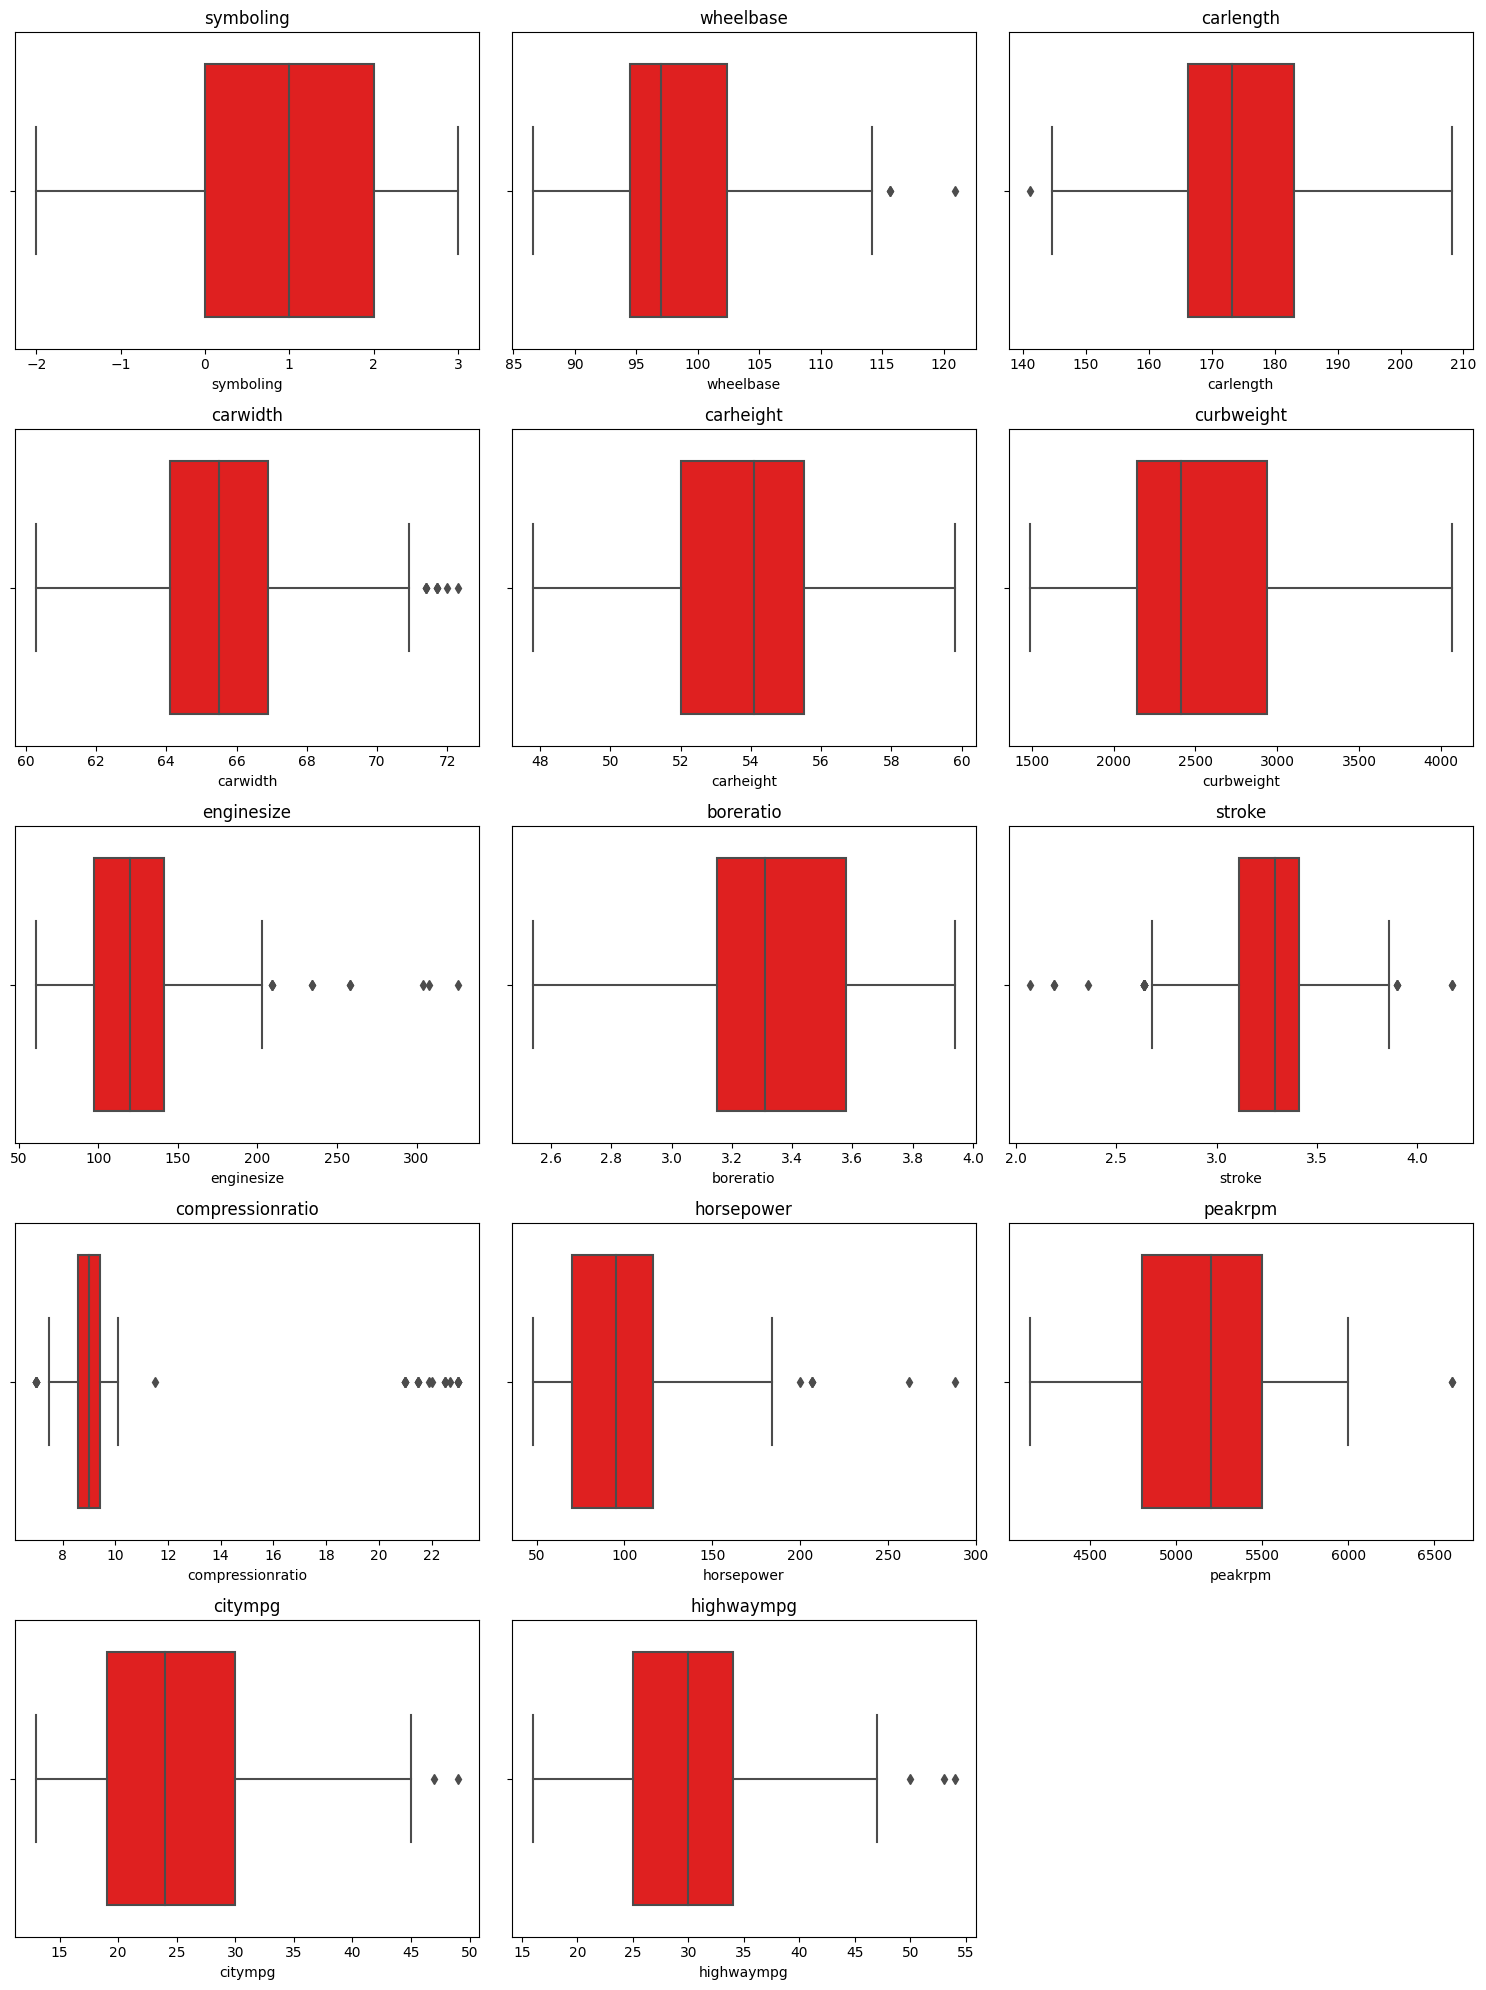

In [19]:
# Jumlah fitur numerik
num_cols = len(num_features)

# Hitung jumlah baris dan kolom subplot (misal: 3 kolom per baris)
cols = 3
rows = (num_cols // cols) + (num_cols % cols > 0)

plt.figure(figsize=(5*cols, 4*rows))

plotnumber = 1
for col in num_features:
    plt.subplot(rows, cols, plotnumber)
    sns.boxplot(data=df, x=col, color='red')
    plt.title(col)
    plotnumber += 1

plt.tight_layout()
plt.show()

In [20]:
def remove_outliers_iqr(df, features):
    df_clean = df.copy()
    for col in features:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    return df_clean

# Misalnya kamu sudah punya list num_features
df_cleaned = remove_outliers_iqr(df, num_features)

# Cek ukuran dataset sebelum dan sesudah
print(f"Sebelum: {df.shape}, Sesudah: {df_cleaned.shape}")


Sebelum: (205, 26), Sesudah: (126, 26)


In [ ]:
# Check the correlation between numerical variables

def plot_cor_num(feature):
    correlations = df[feature].corr(method='spearman')

    plt.figure(figsize=(8, 6))
    sns.heatmap(correlations, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title('Spearman Correlation Heatmap')
    plt.show()

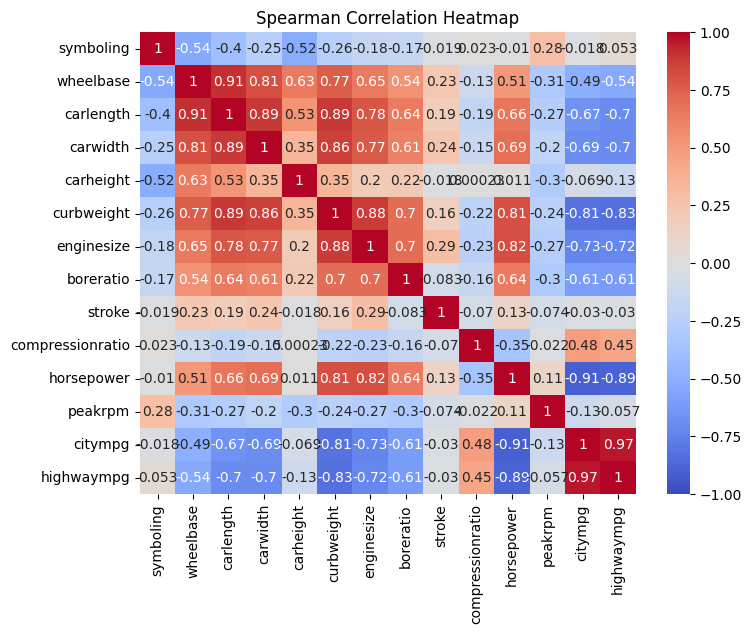

In [ ]:
plot_cor_num(num_features)

Berikut adalah keterangan analisis korelasi berdasarkan heatmap Spearman 
|r| > 0.80 → sangat kuat

0.60 < |r| ≤ 0.80 → kuat

0.40 < |r| ≤ 0.60 → sedang

0.20 < |r| ≤ 0.40 → lemah

|r| ≤ 0.20 → sangat lemah/tidak berkorelasi

[Segmentasi kuatnya korelasi dalam suatu selang](https://www.bmj.com/about-bmj/resources-readers/publications/statistics-square-one/11-correlation-and-regression)

Untuk penggunaan deep learning dengan TensorFlow, multikolinearitas tidak harus dihindari, tapi mengurangi fitur yang sangat redundan tetap bermanfaat demi:

mempercepat training,

menghindari overfitting,

menyederhanakan input layer,

mempermudah interpretasi/analisis hasil jika dibutuhkan.

Berikut daftar fitur yang sebaiknya dikurangi atau hanya dipilih satu di antaranya, berdasarkan korelasi kuat & sangat kuat:

🔻 1. wheelbase, carlength, carwidth, curbweight
Semuanya menggambarkan ukuran fisik mobil.

Korelasi antar mereka sangat tinggi (r > 0.85).

➤ Rekomendasi:
Pilih 2 saja:
carwidth → mewakili lebar/kabin

curbweight → mewakili ukuran + berat

🔻 2. enginesize, horsepower, curbweight
Mesin besar → lebih berat → lebih bertenaga.

Korelasi sangat kuat.

➤ Rekomendasi:
Simpan hanya enginesize
(horsepower dan curbweight sudah cukup terwakili)

🔻 3. highwaympg, citympg
Korelasi sangat kuat (r = 0.97)

➤ Rekomendasi:
Simpan satu saja, misalnya: citympg (lebih relevan untuk penggunaan sehari-hari)

🔻 4. carlength dan wheelbase
Keduanya punya korelasi sangat kuat (r = 0.91)

➤ Rekomendasi:
Drop wheelbase, cukup pertahankan carlength jika tidak pakai carwidth

| Fitur              | Alasan                                     |
| ------------------ | ------------------------------------------ |
| `symboling`        | Independen, bisa bawa info risiko          |
| `enginesize`       | Inti dari performa mesin                   |
| `carwidth`         | Representasi ukuran + kenyamanan           |
| `compressionratio` | Terkait efisiensi mesin                    |
| `citympg`          | Efisiensi konsumsi bahan bakar             |
| `carheight`        | Dimensi vertikal (tidak terlalu korelatif) |



In [21]:
selected_features_numerical = [
    'symboling',
    'carwidth',
    'enginesize',
    'compressionratio',
    'citympg',
    'carheight'
]


## Categorical Feature

In [14]:
cat_features = [feature for feature in df.columns if ((df[feature].dtypes == 'O') & (feature != 'Churn') & (feature != 'customerID' ))]
cat_features

['CarName',
 'fueltype',
 'aspiration',
 'doornumber',
 'carbody',
 'drivewheel',
 'enginelocation',
 'enginetype',
 'cylindernumber',
 'fuelsystem']

Pemeriksaan Kardinalitas Data dan Jenis Kategorikal (Ordinal / Nominal)

In [15]:
pd.set_option('display.max_colwidth', 1)

# Unique values in each column
listItem = []
for col in cat_features :
    listItem.append( [col, df[col].nunique(), df[col].unique()])

tabel1Desc = pd.DataFrame(columns=[['Column Name', 'Number of Unique', 'Unique Sample']],
                     data=listItem)
tabel1Desc

,Column Name,Number of Unique,Unique Sample
0,CarName,147,"[alfa-romero giulia, alfa-romero stelvio, alfa-romero Quadrifoglio, audi 100 ls, audi 100ls, audi fox, audi 5000, audi 4000, audi 5000s (diesel), bmw 320i, bmw x1, bmw x3, bmw z4, bmw x4, bmw x5, chevrolet impala, chevrolet monte carlo, chevrolet vega 2300, dodge rampage, dodge challenger se, dodge d200, dodge monaco (sw), dodge colt hardtop, dodge colt (sw), dodge coronet custom, dodge dart custom, dodge coronet custom (sw), honda civic, honda civic cvcc, honda accord cvcc, honda accord lx, honda civic 1500 gl, honda accord, honda civic 1300, honda prelude, honda civic (auto), isuzu MU-X, isuzu D-Max , isuzu D-Max V-Cross, jaguar xj, jaguar xf, jaguar xk, maxda rx3, maxda glc deluxe, mazda rx2 coupe, mazda rx-4, mazda glc deluxe, mazda 626, mazda glc, mazda rx-7 gs, mazda glc 4, mazda glc custom l, mazda glc custom, buick electra 225 custom, buick century luxus (sw), buick century, buick skyhawk, buick opel isuzu deluxe, buick skylark, buick century special, buick regal sport coupe (turbo), mercury cougar, mitsubishi mirage, mitsubishi lancer, mitsubishi outlander, mitsubishi g4, mitsubishi mirage g4, mitsubishi montero, mitsubishi pajero, Nissan versa, nissan gt-r, nissan rogue, nissan latio, nissan titan, nissan leaf, nissan juke, nissan note, nissan clipper, nissan nv200, nissan dayz, nissan fuga, nissan otti, nissan teana, nissan kicks, peugeot 504, peugeot 304, peugeot 504 (sw), peugeot 604sl, peugeot 505s turbo diesel, plymouth fury iii, plymouth cricket, plymouth satellite custom (sw), plymouth fury gran sedan, plymouth valiant, plymouth duster, porsche macan, porcshce panamera, porsche cayenne, porsche boxter, renault 12tl, ...]"
1,fueltype,2,"[gas, diesel]"
2,aspiration,2,"[std, turbo]"
3,doornumber,2,"[two, four]"
4,carbody,5,"[convertible, hatchback, sedan, wagon, hardtop]"
5,drivewheel,3,"[rwd, fwd, 4wd]"
6,enginelocation,2,"[front, rear]"
7,enginetype,7,"[dohc, ohcv, ohc, l, rotor, ohcf, dohcv]"
8,cylindernumber,7,"[four, six, five, three, twelve, two, eight]"
9,fuelsystem,8,"[mpfi, 2bbl, mfi, 1bbl, spfi, 4bbl, idi, spdi]"
